## 1. Team Formation and Dataset

This repository will be used by the team **Waveform Warriors** to collaborate on the Data Analysis Final assignment.

Team consists of:

- Juanith Mathew Thomas
- Kornel Lengl

We will work on analysing **Rossmann Store Sales** found on Kaggle: https://www.kaggle.com/datasets/pratyushakar/rossmann-store-sales

The *train.csv* and *test.csv* datasets have several entries of 1115 stores, their sales, ongoing discounts, etc. over a period of about 3 years. <br>
Features like their competitor stores and distance to them are also mentioned in the metadata dataset *store.csv.*

In [342]:
import pandas as pd
import numpy as np
from sklearn.model_selection import *
import matplotlib.pyplot as plt
from random import *
import seaborn as sns

In [343]:
df_complete = pd.read_csv("data/train.csv", low_memory=False)

In [344]:
df_complete.shape

(1017209, 9)

In [345]:
df_tail = df_complete.tail(n=406974)                        # Taking 365 day sales of each 1115 stores. Data in head is skewed.
df_head = df_complete.head(n=406975)

#df = df_tail.drop(df_tail[df_tail['Store'] == 1115].index[0])
# insertion = df_head[df_head['Store'] == 988].sample(1, random_state=42)
# df = pd.concat([df, insertion], ignore_index=True)

df = df_tail                                                          # This dataset will be used moving forward.

## 2. Task Categories and Points

### 2.1: Data Preprocessing and Data Quality


#### • Dataset overview

In [346]:
print ("1. The dimensions of the dataset are: ", df.shape, end="\n\n")                                              # Dimensions
print ("2. The columns in this dataset are: ", df.columns.values, end="\n\n")                                       # Columns
print ("3. The data type of each feature in this dataset: \n" + df.dtypes.to_string(), end="\n\n")                  # Types
print (f"4. Time series range of this dataset is from {min(df['Date'])} to {max(df['Date'])}", end="\n\n")          # Time range
print ("5. The sampling rate of the data is 1 day. Each store tracks and report the daily sales.")      # Sampling rate

1. The dimensions of the dataset are:  (406974, 9)

2. The columns in this dataset are:  ['Store' 'DayOfWeek' 'Date' 'Sales' 'Customers' 'Open' 'Promo'
 'StateHoliday' 'SchoolHoliday']

3. The data type of each feature in this dataset: 
Store             int64
DayOfWeek         int64
Date             object
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64

4. Time series range of this dataset is from 01-01-2013 to 31-12-2013

5. The sampling rate of the data is 1 day. Each store tracks and report the daily sales.


In [347]:
missing_count = df.isnull().sum()
print (f"6. Missingness summary: \n{missing_count}")                                                                # Missingness summary

6. Missingness summary: 
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


#### • Basic statistical analysis using pandas 

In [348]:
print ("1. Description of the dataset: ")                      # Descriptives
df.describe()

1. Description of the dataset: 


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,406974.000000,406974.000000,406974.000000,406974.000000,406974.000000,406974.000000,406974.000000
mean,557.998943,3.994525,5658.533675,629.043686,0.830380,0.369864,0.188774
std,321.872731,1.999995,3821.166174,464.764530,0.375299,0.482768,0.391329
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,279.000000,2.000000,3615.000000,394.000000,1.000000,0.000000,0.000000
50%,558.000000,4.000000,5598.000000,603.000000,1.000000,0.000000,0.000000
75%,837.000000,6.000000,7691.000000,833.000000,1.000000,1.000000,0.000000
max,1115.000000,7.000000,38025.000000,7388.000000,1.000000,1.000000,1.000000


In [349]:
print ("2. Grouped stats of the dataset: ")                    # Grouped stats
df.info()                                                      # Not sure if this is exactly what's expected.

2. Grouped stats of the dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406974 entries, 610235 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Store          406974 non-null  int64 
 1   DayOfWeek      406974 non-null  int64 
 2   Date           406974 non-null  object
 3   Sales          406974 non-null  int64 
 4   Customers      406974 non-null  int64 
 5   Open           406974 non-null  int64 
 6   Promo          406974 non-null  int64 
 7   StateHoliday   406974 non-null  object
 8   SchoolHoliday  406974 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 27.9+ MB


In [350]:
Q1 = df['Sales'].quantile(0.25)                                # Quantiles and the IQR value
Q2 = df['Sales'].quantile(0.50)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 = {Q1}")
print(f"Median = {Q2}")
print(f"Q3 = {Q3}")
print(f"IQR = {IQR}")

Q1 = 3615.0
Median = 5598.0
Q3 = 7691.0
IQR = 4076.0


#### • Original data quality analysis with visualization 

In [351]:
missing = df.isnull().sum()                                     # Missingness patterns
missing_pct = (missing / len(df)) * 100

missing_pct

Store            0.0
DayOfWeek        0.0
Date             0.0
Sales            0.0
Customers        0.0
Open             0.0
Promo            0.0
StateHoliday     0.0
SchoolHoliday    0.0
dtype: float64

In [352]:
for col in df.select_dtypes(include=['number']).columns:                        # Outliers
    if col == "Open":
        print("Open:            These are binary values, so applying IQR on them is basically useless.")
        print(f"  0: {sum(df['Open'] == 0)} rows, 1: {sum(df['Open'] == 1)} rows")
    
    elif col == "Promo":
        print("Promo:")
        print(f"  0: {sum(df['Promo'] == 0)} rows, 1: {sum(df['Promo'] == 1)} rows")

    elif col == "SchoolHoliday":
        print("SchoolHoliday:")
        print(f"  0: {sum(df['SchoolHoliday'] == 0)} rows, 1: {sum(df['SchoolHoliday'] == 1)} rows")

    else:
        print(f"{col}:")
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR                                  # 'StateHoliday' and 'Date' not included since those are objects, not numeric data types.
        
        out_low  = df[df[col] < lower].shape[0]
        out_high = df[df[col] > upper].shape[0]
        
        print(f"  Range: {df[col].min():.2f} → {df[col].max():.2f}")
        print(f"  IQR outlier bounds: {lower:.2f} ↔ {upper:.2f}")
        print(f"  Outliers: {out_low} below, {out_high} above")

Store:
  Range: 1.00 → 1115.00
  IQR outlier bounds: -558.00 ↔ 1674.00
  Outliers: 0 below, 0 above
DayOfWeek:
  Range: 1.00 → 7.00
  IQR outlier bounds: -4.00 ↔ 12.00
  Outliers: 0 below, 0 above
Sales:
  Range: 0.00 → 38025.00
  IQR outlier bounds: -2499.00 ↔ 13805.00
  Outliers: 0 below, 11167 above
Customers:
  Range: 0.00 → 7388.00
  IQR outlier bounds: -264.50 ↔ 1491.50
  Outliers: 0 below, 15372 above
Open:            These are binary values, so applying IQR on them is basically useless.
  0: 69031 rows, 1: 337943 rows
Promo:
  0: 256449 rows, 1: 150525 rows
SchoolHoliday:
  0: 330148 rows, 1: 76826 rows


In [353]:
exact_dup_rows = df.duplicated(keep=False).sum()                                # Duplicate entries
print(f"Exact duplicate rows: {exact_dup_rows} out of {len(df)}")

Exact duplicate rows: 0 out of 406974


In [354]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)                          # Timestamp gaps
sorted_time = df['Date'].dropna().sort_values()
time_gaps = sorted_time.diff()

print(f"Min gap: {time_gaps.min()}")
print(f"Max gap: {time_gaps.max()}")
print(f"Mean gap (of the whole dataset): {time_gaps.mean()}")

random_shop = randint(1, 1115)
dates_series = pd.Series(df[df['Store'] == random_shop]['Date'].sort_values().unique())
print(f"\nMean gap (of shop no. {random_shop}): {dates_series.diff().mean()}")

Min gap: 0 days 00:00:00
Max gap: 1 days 00:00:00
Mean gap (of the whole dataset): 0 days 00:01:17.276870947

Mean gap (of shop no. 838): 1 days 00:00:00


C:\Users\gemma\AppData\Local\Temp\ipykernel_14840\3138987141.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)                          # Timestamp gaps


In [355]:
# Only the columns 'Sales' can have inconsistent units.
Serial = 0
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
lowerlimit = Q1 - 1.5 * (Q3 - Q1)
upperlimit = Q3 + 1.5 * (Q3 - Q1)

for sales in df['Sales']:
    if sales > upperlimit:
        Serial += 1

print (f"Number of outlier sales days {Serial} out of {len(df['Sales'])}")

# The dataset was obtained from Kaggle.
# Metadata has confirmed that all the stores from which the data was obtained were German stores.
# It is reasonably safe to assume all sales were in Euros since there's no great way of figuring out inconsistent units.
# Outliers do exist but nothing too drastic to suggest sale reports in a considerably weaker currency.

Number of outlier sales days 11167 out of 406974


#### • Data preprocessing pipeline

In [356]:
df_clean = df[df['Sales'] > 0].reset_index(drop=True)                       # Cleaning steps
remaining_stores = len(df) - len(df_clean)

print(f"Removing {remaining_stores} closed store days ({100*(remaining_stores)/len(df):0.2f}%)")

Removing 69050 closed store days (16.97%)


In [357]:
print(df_clean.isnull().sum())                                              # No missing data

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


In [358]:
df_clean_again = df_clean[(df_clean['Sales'] >= lowerlimit) & (df_clean['Sales'] <= upperlimit)]
remaining_stores = len(df_clean) - len(df_clean_again)

print(f"{remaining_stores} outlier store entries ({100*(remaining_stores)/len(df):0.2f}%)")

11167 outlier store entries (2.74%)


In [359]:
df_clean_again = df_clean.copy()                                      # Basic feature engineering
df_clean_again['IsWeekend'] = (df_clean_again['DayOfWeek'] >= 5).astype(int)

In [360]:
df_complete                 # Original dataframe

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,31-07-2015,5263,555,1,1,0,1
1,2,5,31-07-2015,6064,625,1,1,0,1
2,3,5,31-07-2015,8314,821,1,1,0,1
3,4,5,31-07-2015,13995,1498,1,1,0,1
4,5,5,31-07-2015,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,01-01-2013,0,0,0,0,a,1
1017205,1112,2,01-01-2013,0,0,0,0,a,1
1017206,1113,2,01-01-2013,0,0,0,0,a,1
1017207,1114,2,01-01-2013,0,0,0,0,a,1


In [361]:
df_clean_again              # Cleaned dataframe

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,IsWeekend
0,1,2,2013-12-31,2362,298,1,0,0,1,0
1,2,2,2013-12-31,2148,268,1,0,0,1,0
2,3,2,2013-12-31,4081,463,1,0,0,1,0
3,4,2,2013-12-31,9813,1323,1,0,0,1,0
4,5,2,2013-12-31,2009,241,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
337919,682,2,2013-01-01,3375,566,1,0,a,1,0
337920,733,2,2013-01-01,10765,2377,1,0,a,1,0
337921,769,2,2013-01-01,5035,1248,1,0,a,1,0
337922,948,2,2013-01-01,4491,1039,1,0,a,1,0


Commentary on what changed in the original vs. cleaned dataset.

Firstly, the size of the dataset reduced. Instead of having 700-1000 entries for each shop, skewed in favor of some, the data was seived to obtain 365 entries of each 1115 shop. <br>
Outliers were counted (not removed). Duplicates were checked for, none present. <br>
Days on which stores had 0 sales were removed since they could negatively impact the pattern learning of the LR model. <br>
Feature engineering added 1 feature to the dataset namely 'IsWeekend' which might help the linear regression better predict the sales of a shop that remains open (and has more sales) on the weekend. 

### 2.2: Visualization and Exploratory Analysis

#### • Time-series visualizations

Text(0, 0.5, 'Sales')

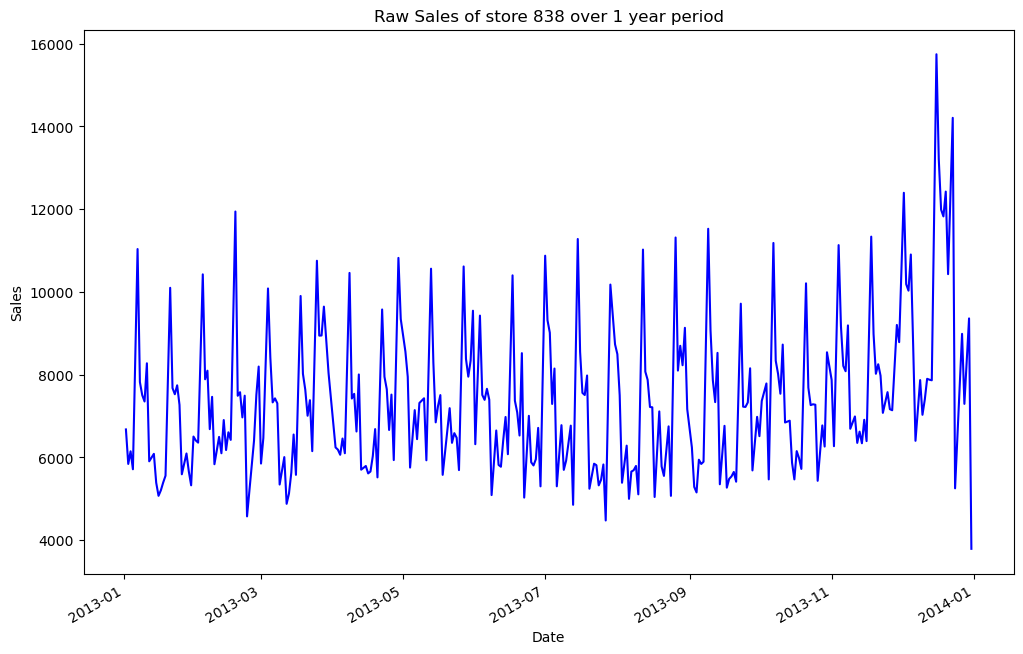

In [362]:
df = df_clean_again               # Reassigning the cleaned dataset to df

store_data = df[df['Store'] == random_shop].copy()
store_data['Date'] = pd.to_datetime(store_data['Date'])
store_data = store_data.sort_values('Date').set_index('Date')

plt.figure(figsize=(12, 8))
store_data['Sales'].plot(title=f"Raw Sales of store {random_shop} over 1 year period", color='blue')       # Raw
plt.ylabel('Sales')

Text(0, 0.5, 'Sales')

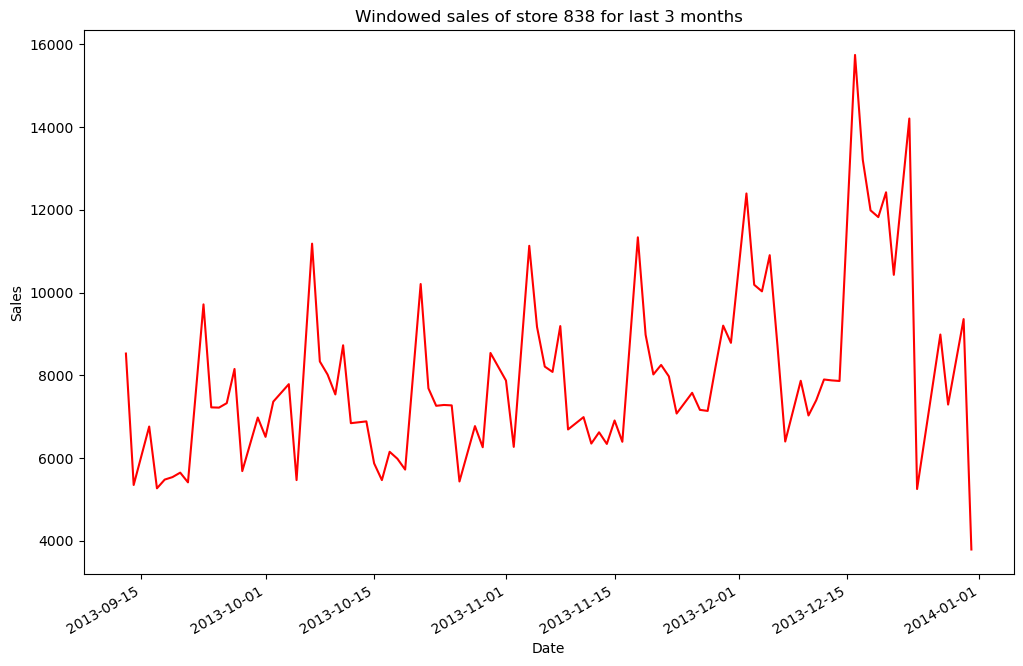

In [363]:
plt.figure(figsize=(12, 8))                                                                                 # Windowed
store_data['Sales'].tail(90).plot(title=f"Windowed sales of store {random_shop} for last 3 months", color='red')
plt.ylabel('Sales')

#### • Distribution analysis with histograms and density style plots 

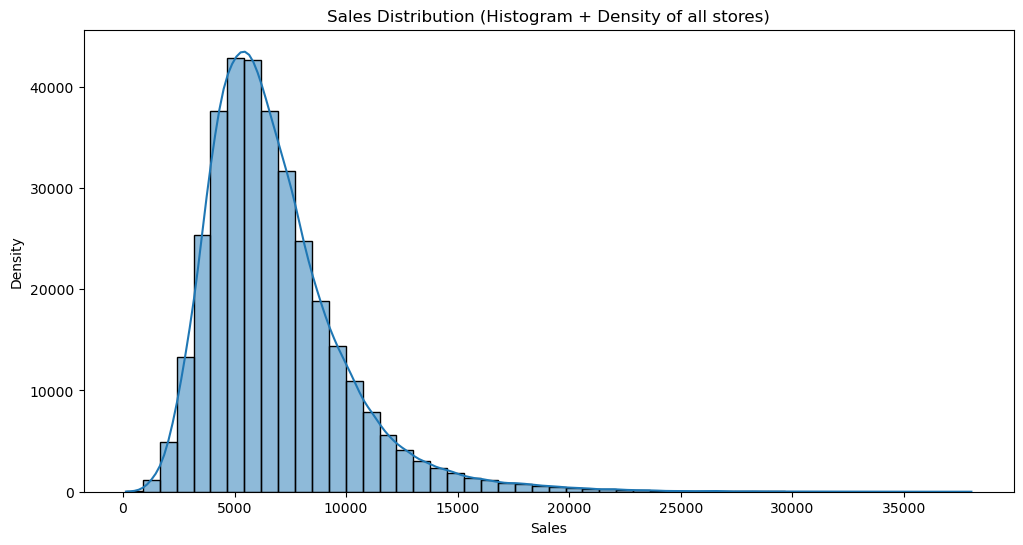

In [364]:
plt.figure(figsize=(12, 6)) 
sns.histplot(data=df, x='Sales', kde=True, bins=50)                 # kernel density estimate (KDE) for the density curve on the bins
plt.title(f'Sales Distribution (Histogram + Density of all stores)')
plt.xlabel('Sales')
plt.ylabel('Density')
plt.show()

#### • Correlation analysis and heatmaps

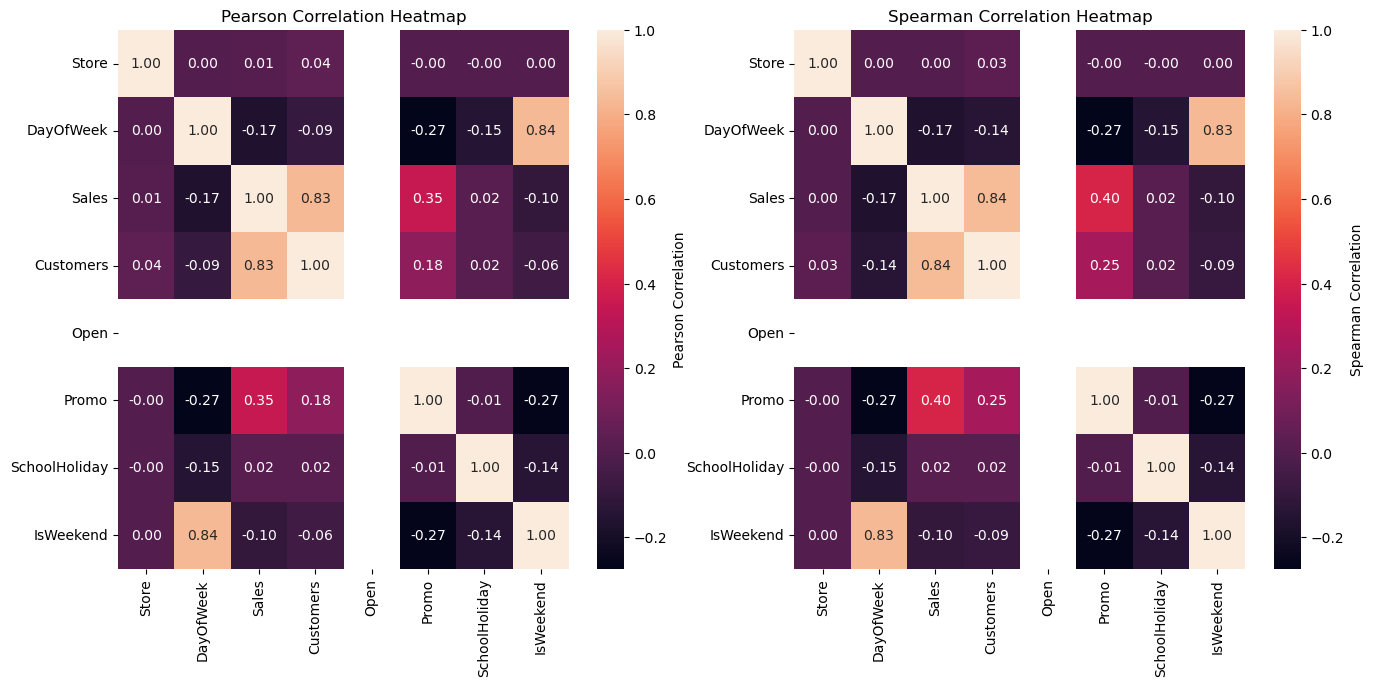

In [365]:
numeric_cols = df.select_dtypes(include=['number']).columns
corr_data = df[numeric_cols]

pearson_corr = corr_data.corr(method='pearson')                             # 1. Pearson correlation
spearman_corr = corr_data.corr(method='spearman')                           # 2. Spearman correlation

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(pearson_corr, annot=True, ax=ax1, fmt='.2f', cbar_kws={'label': 'Pearson Correlation'})
ax1.set_title('Pearson Correlation Heatmap')

sns.heatmap(spearman_corr, annot=True, ax=ax2, fmt='.2f', cbar_kws={'label': 'Spearman Correlation'})
ax2.set_title('Spearman Correlation Heatmap')

plt.show()

##### Interpretation of the above heatmaps

As expected, the correlation is quite similar for both in most aspects, subtle differences caused by the difference in method of correlation calculation. <br>
Since our dataset:
1. Doesn't have outliers
2. Is sufficiently large
3. Not skewed towards the tail

Pearson correlation is pretty sufficient for correlation analysis and we don't necessarily need to employ spearman method.

#### • Daily or periodic pattern analysis

In [366]:
store_data = store_data.reset_index()
store_data

,Date,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,IsWeekend
0,2013-01-02,838,3,6674,740,1,0,0,1,0
1,2013-01-03,838,4,5840,735,1,0,0,1,0
2,2013-01-04,838,5,6145,732,1,0,0,1,1
3,2013-01-05,838,6,5711,677,1,0,0,0,1
4,2013-01-07,838,1,11035,1089,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
298,2013-12-24,838,2,5250,567,1,0,0,1,0
299,2013-12-27,838,5,8985,917,1,0,0,1,1
300,2013-12-28,838,6,7292,792,1,0,0,0,1
301,2013-12-30,838,1,9358,994,1,0,0,1,0


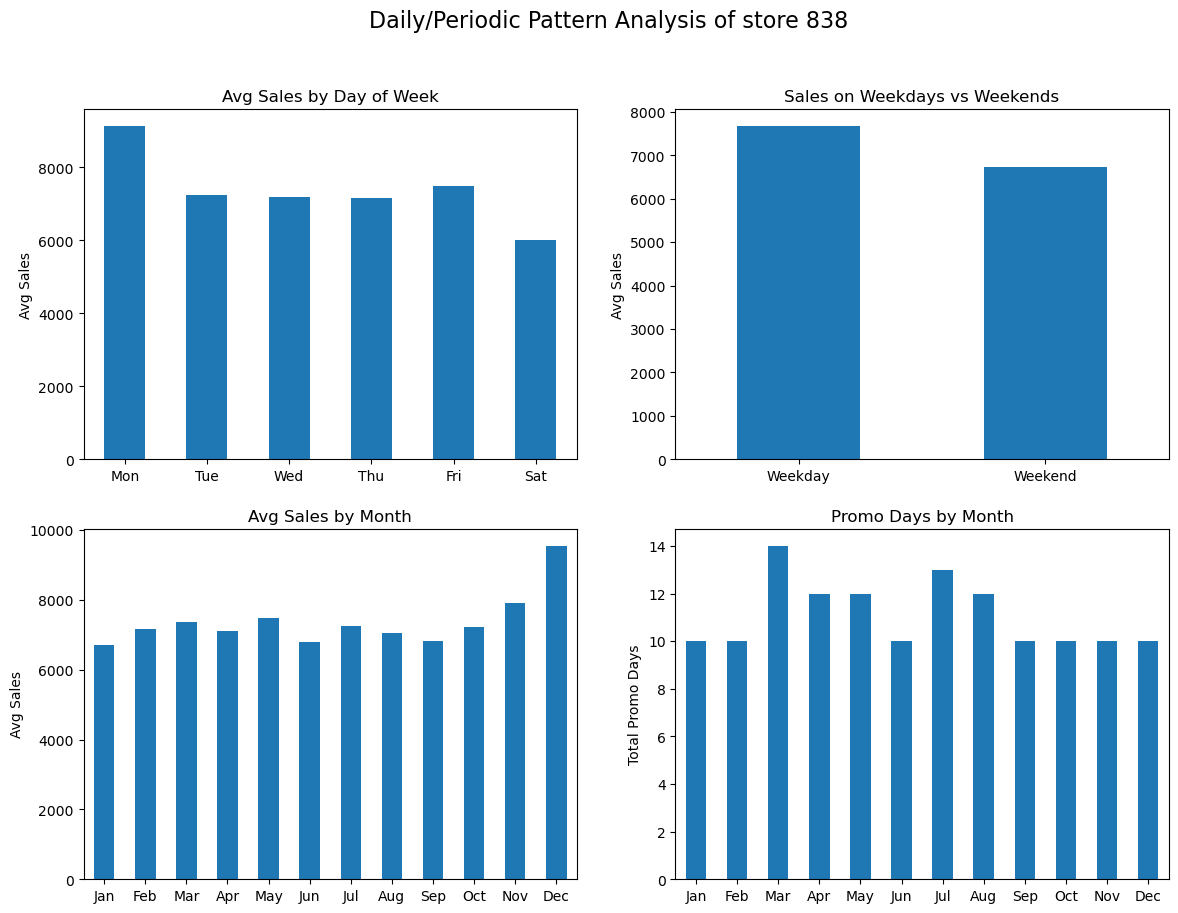

In [367]:
store_data['date'] = pd.to_datetime(store_data['Date'])
store_data['dayOfWeek'] = store_data['Date'].dt.dayofweek
store_data['month'] = store_data['Date'].dt.month

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Daily/Periodic Pattern Analysis of store {random_shop}', fontsize=16)

day_means = store_data.groupby('DayOfWeek')['Sales'].mean()                             # Day-of-week pattern
day_means.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
day_means.plot(kind='bar', ax=axes[0, 0], title='Avg Sales by Day of Week')
axes[0, 0].set_ylabel('Avg Sales')
axes[0, 0].tick_params(axis='x', rotation=0)

day_means = store_data.groupby('IsWeekend')['Sales'].mean()                             # Weekend vs Weekday pattern
day_means.index = ['Weekday', 'Weekend']
day_means.plot(kind='bar', ax=axes[0, 1], title='Sales on Weekdays vs Weekends')
axes[0, 1].set_ylabel('Avg Sales')
axes[0, 1].tick_params(axis='x', rotation=0)

month_means = store_data.groupby('month')['Sales'].mean()                               # Monthly pattern
month_means.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_means.plot(kind='bar', ax=axes[1, 0], title='Avg Sales by Month')
axes[1, 0].set_ylabel('Avg Sales')
axes[1, 0].tick_params(axis='x', rotation=0)

day_means = store_data.groupby('month')['Promo'].sum()                                  # Promo pattern
day_means.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
day_means.plot(kind='bar', ax=axes[1, 1], title='Promo Days by Month')
axes[1, 1].set_ylabel('Total Promo Days')
axes[1, 1].tick_params(axis='x', rotation=0)

#### • Summary of observed patterns

**Days of the week pattern**

    - Although individual stores show large deviations in sales across different days of the week, across all 1,115 stores Monday is the strongest sales day.
    - Evidence: In the Average Sales by Day of Week bar plot, Mondays have the highest mean sales, and Saturdays the lowest.

**Weekday vs Weekend pattern**

    - Generally, weekdays are stronger sales days than weekends, although several individual stores sell more on Saturdays. 
    - Evidence: The Sales on Weekdays vs Weekends plot shows a clear preference for weekdays.

**Monthly sales pattern**

    - December is by far the strongest sales month.
    - Evidence: The Average Sales by Month (Seasonality) plot clearly shows that most sales occur in December.

**Promo vs Seasonality**

    - Seasonality has a stronger influence on sales than promotions.
    - Evidence: The Promo Days by Month plot shows that December has the fewest promo days, yet the Average Sales by Month (Seasonality) plot shows it has the highest sales. March has the most promo days and the second‑highest sales, which indicates that although promotions have less impact than seasonality, they are still effective.


### 2.3: Probability and Event Analysis

1. Define event: The event we define is "high sales days". So a day where the sale > threshold is classified as a *high sales day* for selected random store.
2. Justify threshold: Arbitrary hard upper threshold will be set at the €10.000,00 and lower threshold will be set at €5.000,00
3. Compute empirical probability: Below we'll compute the empirical probability

#### • Threshold-based probability estimation for events

In [368]:
threshold = store_data['Sales'].quantile(0.9)
event = store_data['Sales'] >= threshold                                    # Justify threshold

p_empirical = event.mean()
count_event = event.sum()

print(f"We consider only store {random_shop}\n")
print(f"High-sales threshold (90th percentile): €{threshold}")
print("High-sales event count:", count_event, "from", len(store_data))
print(f"Empirical probability P(event):{100 * p_empirical: .03f}%")         # Compute empirical probability

We consider only store 838

High-sales threshold (90th percentile): €10071.400000000001
High-sales event count: 31 from 303
Empirical probability P(event): 10.231%


#### • Cross tabulation analysis for two variables 

In [369]:
ct_pct = pd.crosstab(store_data['Promo'], store_data['IsWeekend'], normalize='index') * 100 
ct_pct.round(2)                                                             # Cross tabs

# Means most of the promos run through the weekdays instead of weekends. 
# Only around 20% of the promos run on a weekend. 

IsWeekend,0,1
Promo,,
0,54.71,45.29
1,80.45,19.55


#### • Conditional probability analysis 

In [370]:
store_data['HighSales'] = (store_data['Sales'] >= threshold).astype(int)

p_high_given_promo1 = store_data.loc[store_data['Promo'] == 1, 'HighSales'].mean()
p_high_given_promo0 = store_data.loc[store_data['Promo'] == 0, 'HighSales'].mean()          # Conditional probability analysis 1 

print(f"P(HighSales | Promo=1): {100 * p_high_given_promo1: .02f} %")
print(f"P(HighSales | Promo=0): {100 * p_high_given_promo0: .02f} %")

P(HighSales | Promo=1):  21.80 %
P(HighSales | Promo=0):  1.18 %


In [371]:
lower_threshold = store_data['Sales'].quantile(0.1)

store_data['LowSales'] = (store_data['Sales'] <= lower_threshold).astype(int)

p_low_given_promo1 = store_data.loc[store_data['Promo'] == 1, 'LowSales'].mean()
p_low_given_promo0 = store_data.loc[store_data['Promo'] == 0, 'LowSales'].mean()            # Conditional probability analysis 2

print(f"P(LowSales | Promo=1): {100 * p_low_given_promo1: .02f} %")
print(f"P(LowSales | Promo=0): {100 * p_low_given_promo0: .02f} %")

P(LowSales | Promo=1):  0.00 %
P(LowSales | Promo=0):  18.24 %


#### • Summary of observations and limitations 
##### Observations
- Promo days show a much higher chance of HighSales than non‑promo days, so promotions are strongly associated with higher sales in this dataset.
- Consecutively, on days where there are no promos, the chance LowSales increases significantly. 
- Promo isn’t assigned randomly; stores may run promos on special dates, high-demand periods, or in specific store types, sofigures can be inflated by other factors (season, holidays, store location/type).

##### Limitations
- HighSales and LowSales depends on a chosen cutoff, changing the cutoff changes the probability a lot so results are not universal.

### 2.4: Statistical Theory Applications

#### • Law of Large Numbers demonstration

In [372]:
df_store = store_data['Sales']
x = df_store.to_numpy()

running_mean = np.cumsum(x) / np.arange(1, len(x) + 1)                  # Law of Large Numbers mathematically
overall_mean = x.mean()

diffs = np.abs(np.diff(running_mean))
print ("You see that the early mean computations swing wildly with these large differences: ")
for i in diffs[:10]:
    print (f"{i:.02f}", end=", ")
print (f"{diffs[10]:.02f}")

print ("\nBut the last few adjustments in the mean stabilize the value and restrict this swing: ")
for i in diffs[-10:-1]:
    print (f"{i:.02f}", end=", ")
print (f"{diffs[-1]:.02f}")

You see that the early mean computations swing wildly with these large differences: 
417.00, 37.33, 127.17, 988.50, 122.83, 42.88, 12.79, 112.61, 146.91, 103.75, 144.70

But the last few adjustments in the mean stabilize the value and restrict this swing: 
16.00, 15.34, 17.26, 10.43, 23.04, 7.07, 5.42, 0.24, 6.60, 11.82


Text(0.5, 1.0, 'Convergence of mean sales of shop 838 over 303 days')

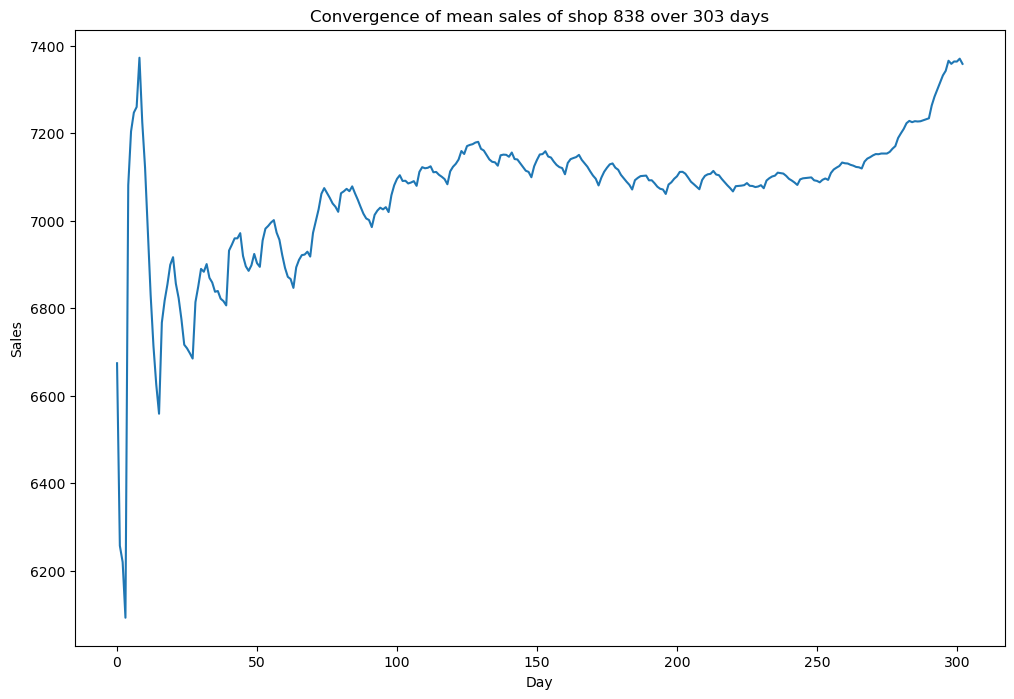

In [399]:
plt.figure(figsize=(12,8))
plt.plot(running_mean)                                                  # Law of Large Numbers graphically 
plt.xlabel("Day")
plt.ylabel("Sales")
plt.title(f"Convergence of mean sales of shop {random_shop} over {len(store_data)} days")

#### • Central Limit Theorem application 

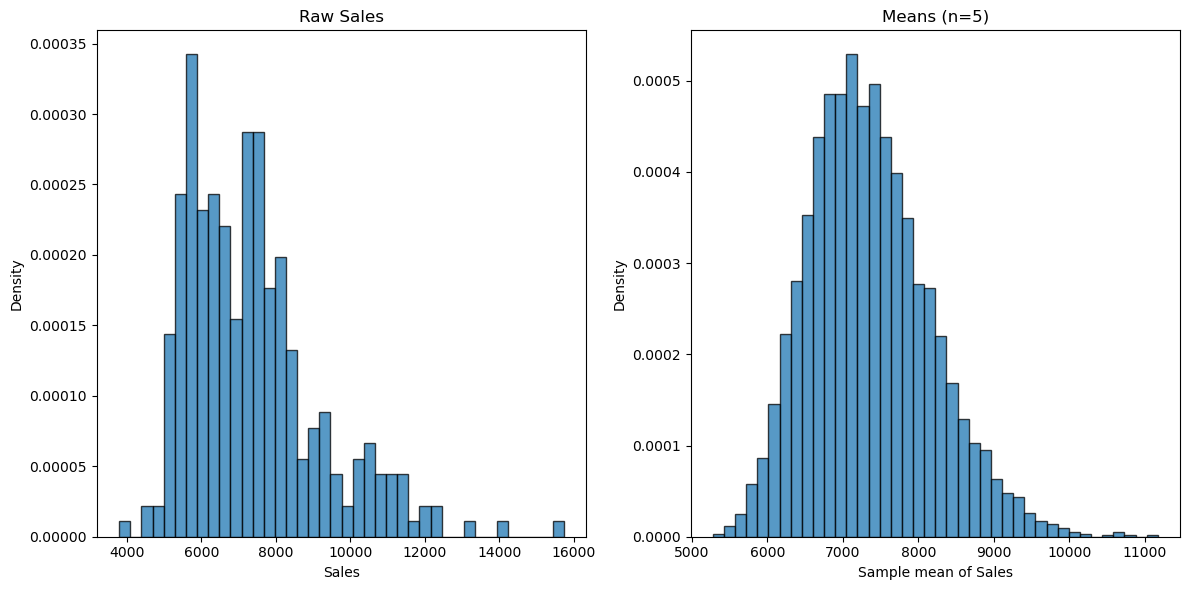

In [374]:
mu_hat = x.mean()
sigma_hat = x.std(ddof=1)

rng = np.random.default_rng(0)
def sample_means(x, n, B=5000):
    samples = rng.choice(x, size=(B, n), replace=True)
    return samples.mean(axis=1)

means = sample_means(x, 5, B=5000)                                  # Sample size = 5

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].hist(x, bins=40, density=True, edgecolor="black", alpha=0.75)
axes[0].set_title("Raw Sales")
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("Density")

axes[1].hist(means, bins=40, density=True, edgecolor="black", alpha=0.75)
axes[1].set_title("Means (n=5)")
axes[1].set_xlabel("Sample mean of Sales")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

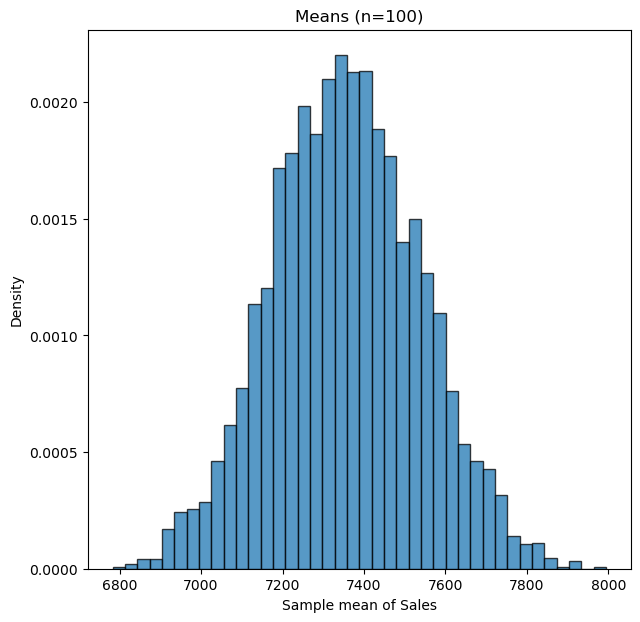

In [375]:
means = sample_means(x, 100, B=5000)                                  # Sample size = 100

plt.figure(figsize=(7,7))
plt.title("Means (n=100)")
plt.xlabel("Sample mean of Sales")
plt.ylabel("Density")
plt.hist(means, bins=40, density=True, edgecolor="black", alpha=0.75)
plt.show()

We can interpret from the above that:
- As the sample size increases, the spread decreases thereby increasing the normality of the graph.
- The bell-shape increases and the histogram is tighter around the mean.

#### • Result interpretation and sanity checks 

##### Observations:
- The running mean of Sales for a fixed store (open days) moved a lot early on and then stabilized near the overall average as more days were included, which is the qualitative behavior LLN predicts.
- When we sampled higher days, larger nn produced a more bell-shaped distribution of means and a narrower spread. 

### 2.5: Regression and Predictive Modeling

In [376]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

#### • Define a prediction target and features

In [377]:
y = df['Sales']
X = df.copy().drop('Date', axis=1)
X = X.drop('Sales', axis=1)

cat_cols = ["StateHoliday"]  # encode these
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop"
)

#### • Linear or polynomial model selection

In [378]:
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("linreg", LinearRegression())                  # 1- Linear regression model selection 
])

poly2_model = Pipeline([
    ("preprocess", preprocess),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linreg", LinearRegression())                  # 2- polynomial regression + Linear regression 
])

#### • Model fitting and validation

In [379]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

poly2_model.fit(X_train, y_train)
model.fit(X_train, y_train)

pred_poly2 = poly2_model.predict(X_test)
y_pred = model.predict(X_test)

#### • Residual analysis and interpretation

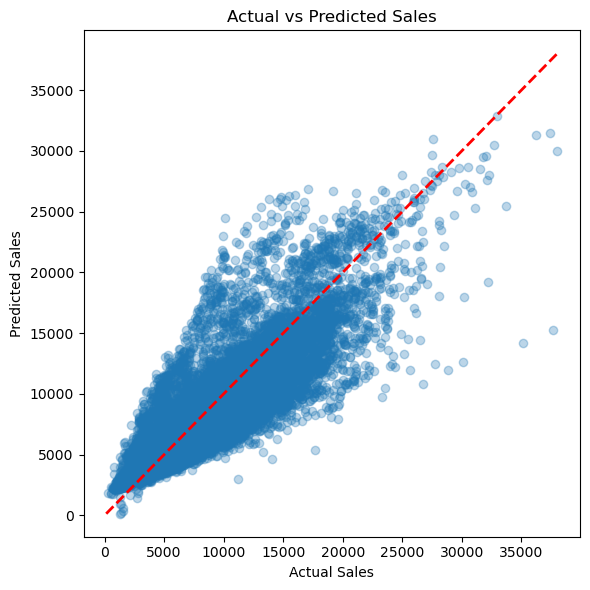

In [380]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)                  # Graph for linear regression

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())
plt.plot([low, high], [low, high], "r--", linewidth=2)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.tight_layout()
plt.show()

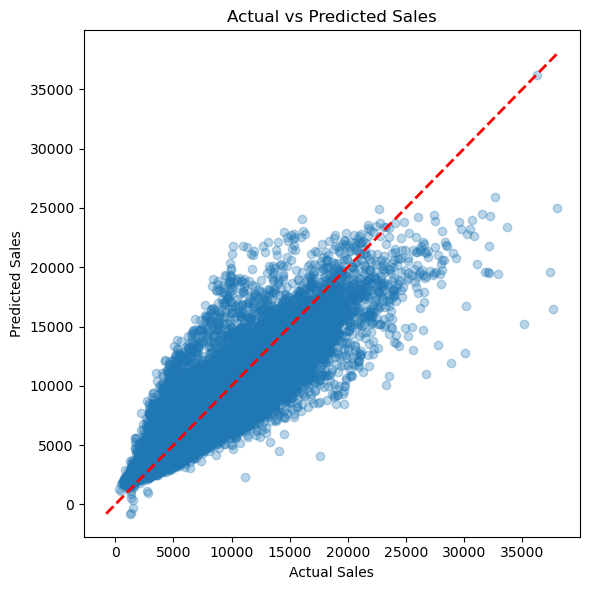

In [381]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_poly2, alpha=0.3)                  # Graph for polynomial regression

low = min(y_test.min(), pred_poly2.min())
high = max(y_test.max(), pred_poly2.max())
plt.plot([low, high], [low, high], "r--", linewidth=2)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.tight_layout()
plt.show()

In [382]:
rmse_lin = root_mean_squared_error(y_test, y_pred)
rmse_poly2 = root_mean_squared_error(y_test, pred_poly2)

r2_lin = r2_score(y_test, y_pred)
r2_poly2 = r2_score(y_test, pred_poly2)

mae_lin = mean_absolute_error(y_test, y_pred)
mae_poly2 = mean_absolute_error(y_test, pred_poly2)

print (f"Root mean square error of the simple linear regression: {rmse_lin:.2f}")
print (f"Root mean square error of the polynomial-2 linear regression: {rmse_poly2:.2f}")

print (f"\nR2 score of the simple linear regression: {r2_lin:.2f}")
print (f"R2 score of the polynomial-2 linear regression: {r2_poly2:.2f}")

print (f"\nMean absolute error of the simple linear regression: {mae_lin:.2f}")
print (f"Mean absolute error of the polynomial-2 linear regression: {mae_poly2:.2f}")

Root mean square error of the simple linear regression: 1568.78
Root mean square error of the polynomial-2 linear regression: 1497.67

R2 score of the simple linear regression: 0.75
R2 score of the polynomial-2 linear regression: 0.77

Mean absolute error of the simple linear regression: 1117.19
Mean absolute error of the polynomial-2 linear regression: 1076.48


Insights:
- RMSE suggests quite a bit of error in predictions created by both the models. Polynomial-2 model being slightly better but overall having an error of about 20%.
- R² = 0.75 means the linear model explains about 75% of the variability in sales in your test data. 0.77 for polynomial model shows that it captures a bit more structure.
- MAE misses by about 1117 sales-units per day for the linear model and 1076 for the poly-2 model. Not great, not terrible.
    
Other reference notebooks were searched and algorithms such as Random Forest, XGBoost show considerably better results with accuracy reaching ~90% instead of ~83% here.

In [383]:
mape = np.mean(np.abs((y_test - pred_poly2) / y_test)) * 100
print(f"MAPE: {mape:.2f}%")
print(f'Forecast "accuracy" (100 - MAPE): {100 - mape:.2f}%')

MAPE: 16.98%
Forecast "accuracy" (100 - MAPE): 83.02%


### 2.6: Dimensionality Reduction and Statistical Tests 

In [384]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df = df.drop('Date', axis=1)

#### • PCA projection and interpretation

In [401]:
cat_cols = ["StateHoliday"]
num_cols = [c for c in X.columns if c not in cat_cols]

prep = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop"
)

pca = PCA(n_components=3, random_state=0)

pipe = Pipeline(steps=[
    ("prep", prep),
    ("scale", StandardScaler(with_mean=False)),
    ("pca", pca)
])

Z = pipe.fit_transform(df)

evr = pipe.named_steps["pca"].explained_variance_ratio_
print(f"Explained variance ratio (PC1, PC2, PC3): {100 * evr[0]:.3f}%, {100 * evr[1]:.3f}% & {100 * evr[2]:.3f}%")
print(f"Cumulative explained variance (PC1+PC2+PC3): {100 * evr.sum():.3f}%")

Explained variance ratio (PC1, PC2, PC3): 20.618%, 19.853% & 10.908%
Cumulative explained variance (PC1+PC2+PC3): 51.379%


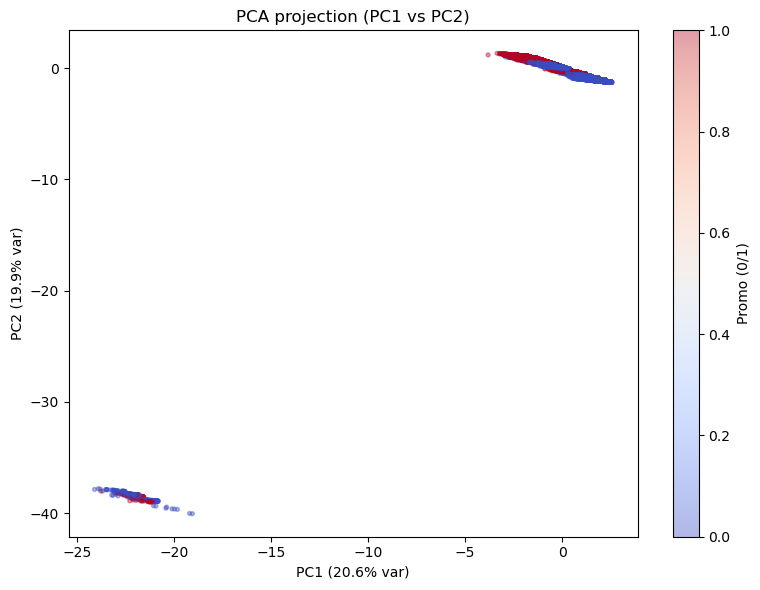

In [ ]:
label = df.loc[X.index, "Promo"].to_numpy()

plt.figure(figsize=(8,6))
sc = plt.scatter(Z[:,0], Z[:,1], c=label, cmap="coolwarm", s=8, alpha=0.4)
plt.xlabel(f"PC1 ({evr[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({evr[1]*100:.1f}% var)")
plt.title("PCA projection (PC1 vs PC2)")
plt.colorbar(sc, label="Promo (0/1)")
plt.tight_layout()
plt.show()

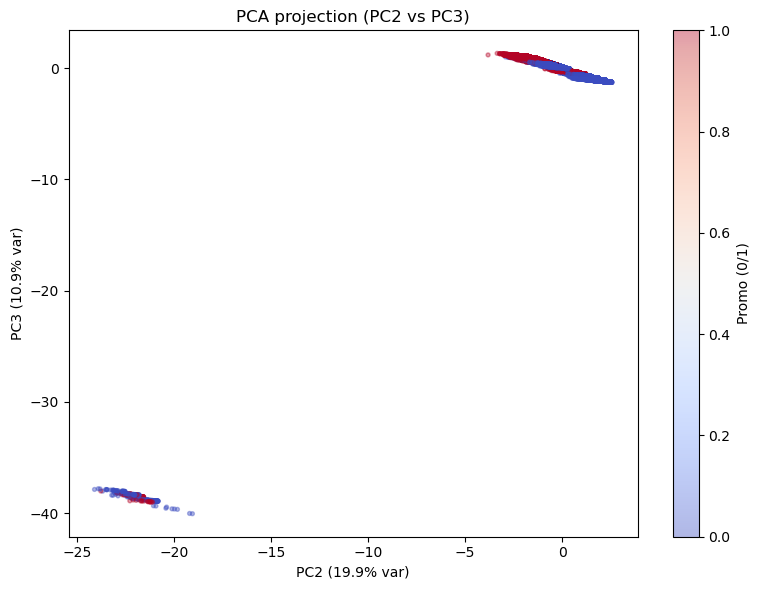

In [405]:
label = df.loc[X.index, "Promo"].to_numpy()

plt.figure(figsize=(8,6))
sc = plt.scatter(Z[:,0], Z[:,1], c=label, cmap="coolwarm", s=8, alpha=0.4)
plt.xlabel(f"PC2 ({evr[1]*100:.1f}% var)")
plt.ylabel(f"PC3 ({evr[2]*100:.1f}% var)")
plt.title("PCA projection (PC2 vs PC3)")
plt.colorbar(sc, label="Promo (0/1)")
plt.tight_layout()
plt.show()

In [409]:

# use the same preprocessed+scaled matrix you fed to PCA before, call it X_ready
X_ready = pipe.named_steps["scale"].transform(pipe.named_steps["prep"].transform(X))
pca_full = PCA().fit(X_ready)
cum = np.cumsum(pca_full.explained_variance_ratio_)

print(f"Cumulative variance at k=2: {100 *cum[1]:.2f}%")
print(f"Cumulative variance at k=3: {100 *cum[2]:.2f}%")
print("k for 80%:", np.argmax(cum >= 0.80) + 1)
print("k for 90%:", np.argmax(cum >= 0.90) + 1)

Cumulative variance at k=2: 40.47%
Cumulative variance at k=3: 51.38%
k for 80%: 6
k for 90%: 7


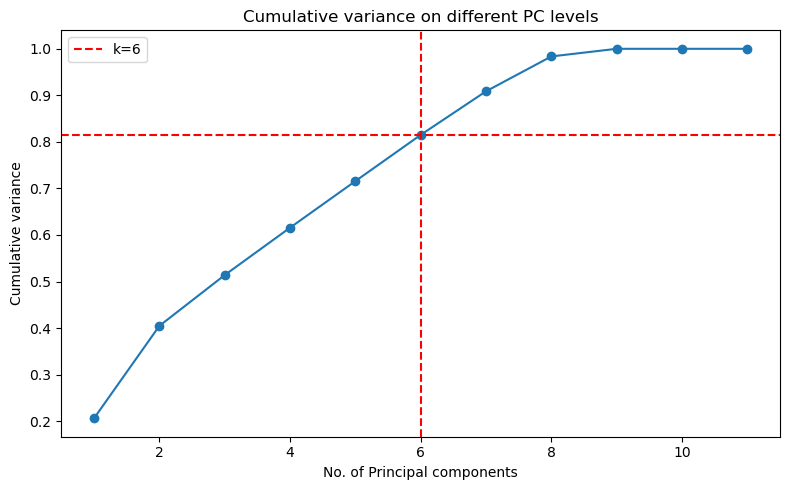

In [388]:
pca_full = PCA().fit(X_ready)
cum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum)+1), cum, marker="o")
plt.axvline(6, color="r", linestyle="--", label="k=6")
plt.axhline(cum[5], color="r", linestyle="--")
plt.xlabel("No. of Principal components")
plt.ylabel("Cumulative variance")
plt.title("Cumulative variance on different PC levels")
plt.legend()
plt.tight_layout()
plt.show()

A cluster in a PCA plot indicates that many rows in our dataset have similar feature patterns, which cause them to end up close to one another after the data is compressed into PC1/PC2. 

When two groups are "separated," it indicates that there is a significant difference in the underlying features. Usually, one variable or combination (such as IsWeekend versus an imaginary feature like IsNotWeekend) causes those rows to differ systematically, therefore PCA places them in different regions.

From the elbow method, we see that we need 8 PCs to actually capture enough data.

#### • t-SNE embedding with justified hyperparameters (perplexity or similar) and interpretation

In [389]:
from sklearn.manifold import TSNE

In [390]:
rng = np.random.default_rng(0)
n = X_ready.shape[0]
idx = rng.choice(n, size=min(10000, n), replace=False)
X_s = X_ready[idx]

X_11 = PCA(n_components=11, random_state=0).fit_transform(X_s)

tsne = TSNE(
    n_components=2,
    perplexity=30,              # seems like this is a good default for smaller sizes like ours.
    learning_rate="auto",
    init="pca",
    random_state=0
)
Z = tsne.fit_transform(X_11)

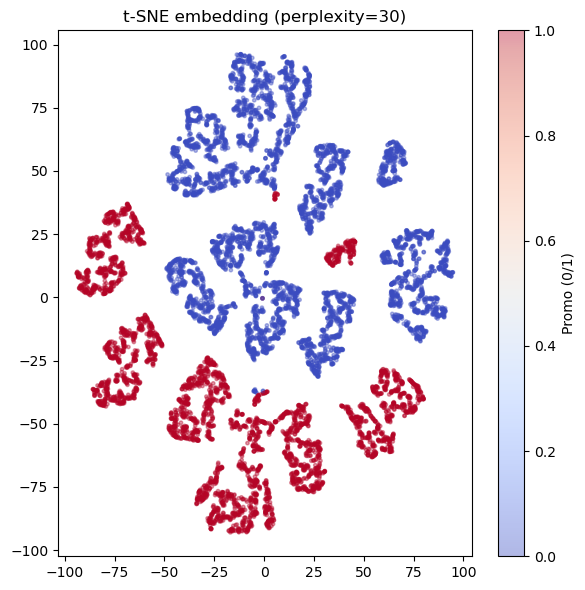

In [391]:
# color by Promo (optional)
promo = df.loc[df.index[idx], "Promo"].to_numpy()

plt.figure(figsize=(6,6))
sc = plt.scatter(Z[:,0], Z[:,1], c=promo, cmap="coolwarm", s=6, alpha=0.4)
plt.colorbar(sc, label="Promo (0/1)")
plt.title("t-SNE embedding (perplexity=30)")
plt.tight_layout()
plt.show()

- Since t-SNE is a distance based method to visualize higher dimensional data more easily, we first sample rows and reduce it to lesser bins using PCA.
- Since we see that Promo regions are different from non-promo regions, there's a fundamental difference between the two.
- The "islands" indicate that the similarly classified features are grouped together.

#### • UMAP embedding with justified hyperparameters

In [392]:
import umap.umap_ as umap

In [393]:
rng = np.random.default_rng(0)
n = X_ready.shape[0]
idx = rng.choice(n, size=min(10000, n), replace=False)
X_s = X_ready[idx]

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=0
)

Z = reducer.fit_transform(X_s)

c:\Users\gemma\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


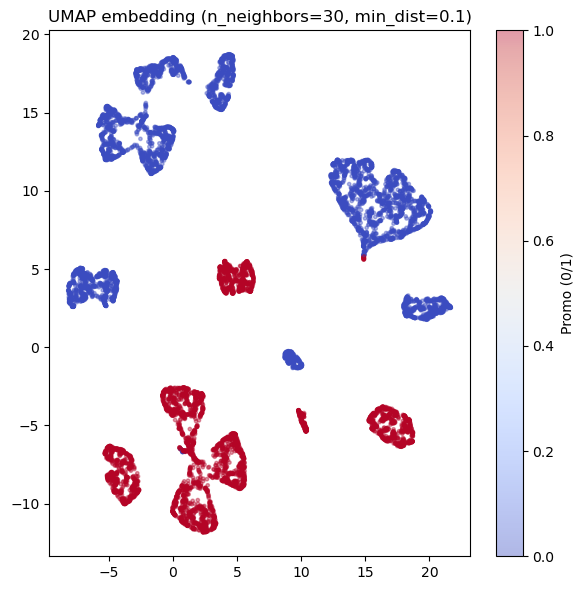

In [394]:
promo = df.loc[df.index[idx], "Promo"].to_numpy()

plt.figure(figsize=(6,6))
sc = plt.scatter(Z[:,0], Z[:,1], c=promo, cmap="coolwarm", s=6, alpha=0.4)
plt.colorbar(sc, label="Promo (0/1)")
plt.title("UMAP embedding (n_neighbors=30, min_dist=0.1)")
plt.tight_layout()
plt.show()

- We observe the local neighbourhoods being preserved.
- Just like we had for t-SNE, we can see quite well defined clusters for when Promo is high/low.

#### • Chi-square test

In [395]:
from scipy.stats import chi2_contingency, ttest_ind

ct = pd.crosstab(df["Promo"], df["IsWeekend"])                          # Chi-square test of independence
chi2, p, dof, expected = chi2_contingency(ct)

print(f"chi2={chi2:.3f}, dof={dof}, p-value={p:.3g}")
ct

chi2=24192.940, dof=1, p-value=0


IsWeekend,0,1
Promo,,
0,104492,86444
1,118060,28928


**We reject the null hypothesis.**

From the above result, we can see that IsWeekend and Promo is actually dependent.

The chances of Promo happening on a weekend are less, about 20%.
In contrast, chances of Promo happening on a weekdat are higher, about 45%.

In [410]:
d = df[df["Open"] == 1].copy()

sales_promo = d.loc[d["Promo"] == 1, "Sales"].to_numpy()
sales_no = d.loc[d["Promo"] == 0, "Sales"].to_numpy()

tstat, pval = ttest_ind(sales_promo, sales_no)                          # Welch t-test

print(f"Mean sales when promo: {sales_promo.mean():.2f}")
print(f"Mean sales when no promo: {sales_no.mean():.2f}")
print(f"\nWelch t-test: t={tstat:.3f}, p={pval:.3g}")

Mean sales when promo: 8063.49
Mean sales when no promo: 5853.48

Welch t-test: t=218.391, p=0


**We reject the null hypothesis again.**

From the above result, we can see that sales when there is a Promo is actually considerably higher.

So, the null hypothesis of no difference is sales based on Promo is rejected.

In [397]:
df

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,IsWeekend
0,1,2,2362,298,1,0,0,1,0
1,2,2,2148,268,1,0,0,1,0
2,3,2,4081,463,1,0,0,1,0
3,4,2,9813,1323,1,0,0,1,0
4,5,2,2009,241,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...
337919,682,2,3375,566,1,0,a,1,0
337920,733,2,10765,2377,1,0,a,1,0
337921,769,2,5035,1248,1,0,a,1,0
337922,948,2,4491,1039,1,0,a,1,0


In [411]:
store_data["Date"] = pd.to_datetime(store_data["Date"])
store_data = store_data.sort_values("Date")

lag1_corr = d["Sales"].autocorr(lag=1)
print(f"Lag-1 autocorrelation: {lag1_corr:.2f}")

Lag-1 autocorrelation: 0.26


This result means that the day by day sales are correlated.

Meaning, we can have high sales on 15 July 2013 (Monday), and there's a decent chance that on 16th July (Tuesday) also, the sales will be high.